In [1]:
import cv2 
import IPython
import numpy as np
import pandas as pd

# from qdrant_client import QdrantClient 
# from qdrant_client.models import Distance, VectorParams, PointStruct

In [2]:
# CLIENT = QdrantClient(host='192.168.0.131', port=6333)   

In [3]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [4]:
def image_from_video(row):
    cap = cv2.VideoCapture(row['filepath'])
    cap.set(cv2.CAP_PROP_POS_FRAMES, row['frame_num'])
    ret, frame = cap.read()
    h, w = (row['img_height'], row['img_width'])
    cv2.rectangle(frame, (int(row['x1'] * w), int(row['y1'] * h)), 
                         (int(row['x2'] * w), int(row['y2'] * h)), (0, 0, 255), 3)
    show_image(frame)

In [5]:
def parse_vector(vector):
    return np.array([float(x) for x in vector.split('\n')])

In [18]:
src = '/home/amos/programs/CineFace/data/faces/the-outsider_2020_8550800/the.outsider.2020.s01e01.BluRay.10Bit.1080p.DDP5.1.H265-d3g.csv'
df = pd.read_csv(src, index_col=0)
df.head()

,x1,y1,x2,y2,right_eye_x,right_eye_y,left_eye_x,left_eye_y,nose_x,nose_y,...,frame_num,img_width,img_height,filepath,encoding,series_id,episode_id,filename,distance_from_center,pct_of_frame
0,0.859,0.429,0.882,0.489,0.865,0.455,0.874,0.452,0.870,0.463,...,1488,1920,960,/home/amos/media/tv/The Outsider 2020 S01 br 1...,-0.113853\n0.0549378\n0.00657476\n-0.0948347\n...,8550800,NaN,the.outsider.2020.s01e01.BluRay.10Bit.1080p.DD...,1073.31,0.0
1,0.871,0.341,0.898,0.409,0.878,0.369,0.890,0.368,0.884,0.379,...,1512,1920,960,/home/amos/media/tv/The Outsider 2020 S01 br 1...,-0.13363\n-0.0017481\n-0.00172096\n-0.12586\n-...,8550800,NaN,the.outsider.2020.s01e01.BluRay.10Bit.1080p.DD...,1073.31,0.0
2,0.891,0.208,0.926,0.301,0.898,0.244,0.913,0.242,0.905,0.257,...,1536,1920,960,/home/amos/media/tv/The Outsider 2020 S01 br 1...,-0.142644\n0.044363\n-0.0399957\n-0.105944\n-0...,8550800,NaN,the.outsider.2020.s01e01.BluRay.10Bit.1080p.DD...,1073.31,0.0
3,0.852,0.000,0.897,0.104,0.857,0.032,0.873,0.028,0.859,0.052,...,1560,1920,960,/home/amos/media/tv/The Outsider 2020 S01 br 1...,-0.0909916\n0.0403318\n0.0755191\n0.0140529\n-...,8550800,NaN,the.outsider.2020.s01e01.BluRay.10Bit.1080p.DD...,1073.31,0.0
4,0.259,0.091,0.291,0.179,0.267,0.128,0.280,0.127,0.273,0.143,...,1944,1920,960,/home/amos/media/tv/The Outsider 2020 S01 br 1...,-0.0468823\n0.076168\n0.0687075\n-0.0731323\n-...,8550800,NaN,the.outsider.2020.s01e01.BluRay.10Bit.1080p.DD...,1073.31,0.0


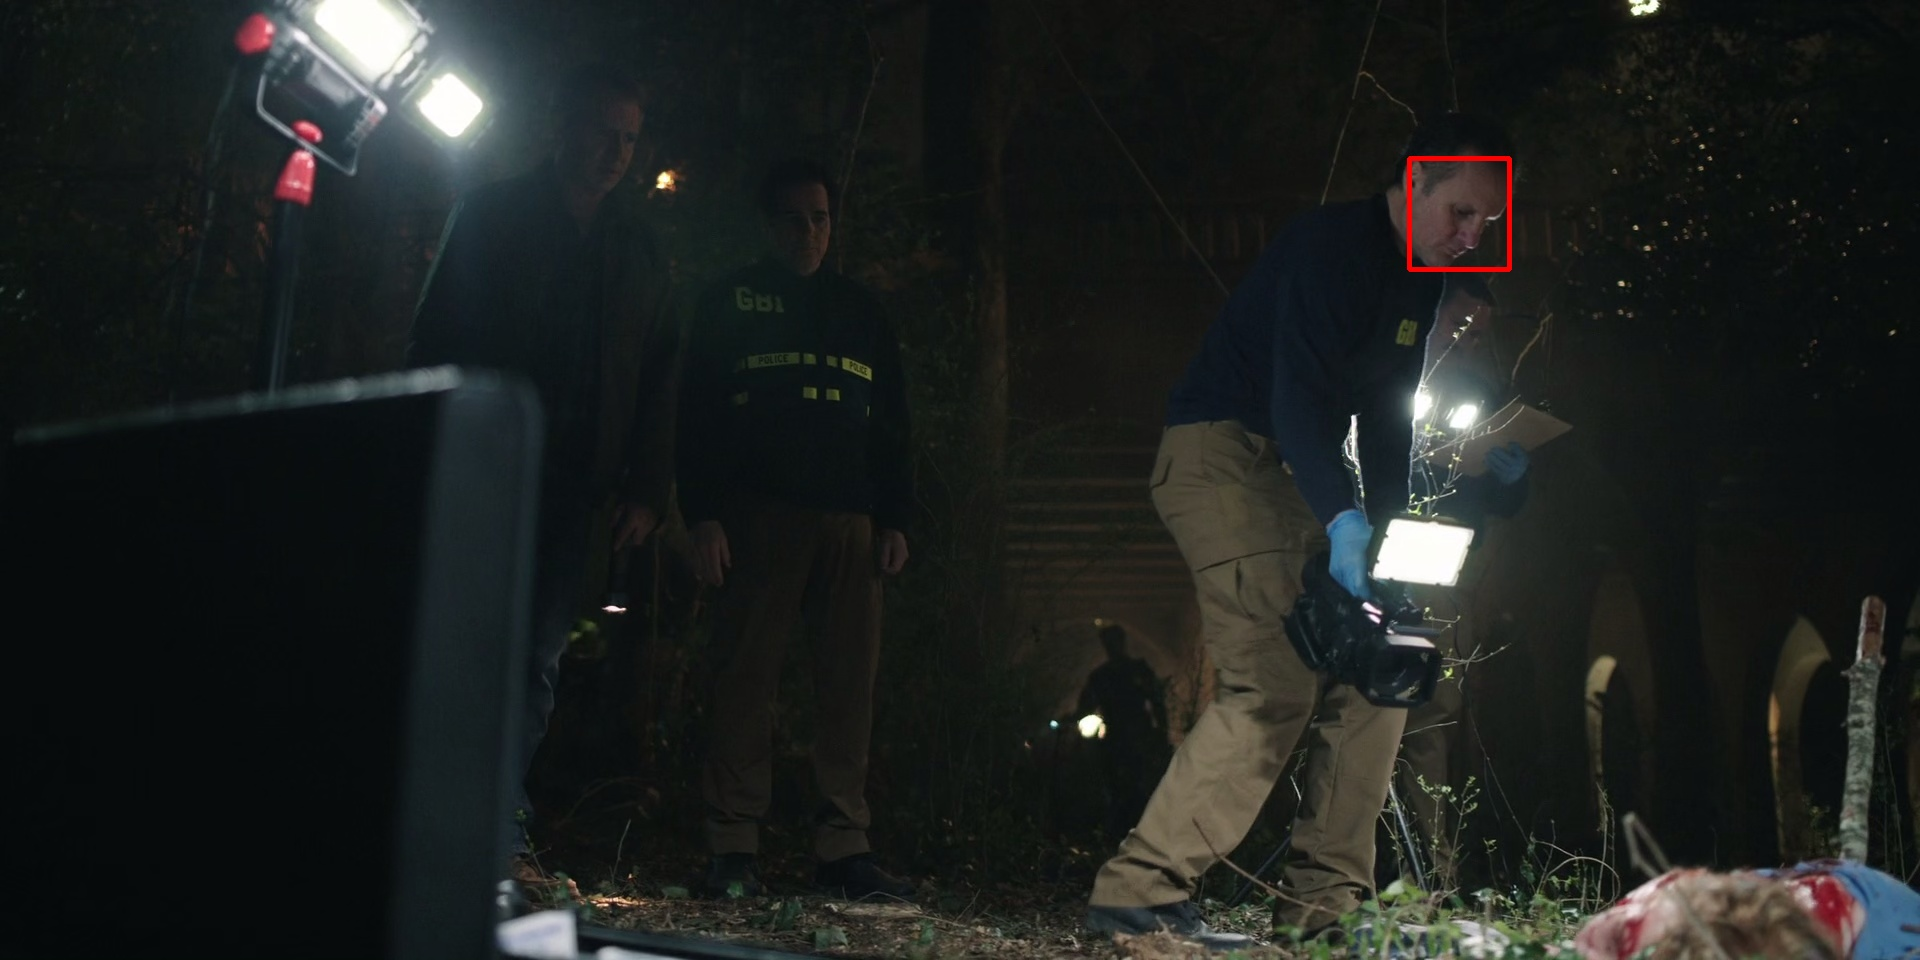

In [22]:
image_from_video(df.iloc[75])